<a href="https://colab.research.google.com/github/Kuoz2/An-lisis_y_Predicci-n/blob/main/Vinos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de Machine Learning para Clasificación
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Métricas de Clasificación
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

### **Nota Científica: Configuración del Entorno y Librerías**

Este bloque inicial configura el entorno de trabajo, importando las librerías esenciales para el análisis de datos, la manipulación numérica, la visualización y las tareas de aprendizaje automático. Se incluyen `pandas` para la gestión de DataFrames, `numpy` para operaciones numéricas, `matplotlib` y `seaborn` para la visualización, y un conjunto de módulos de `sklearn` para preprocesamiento de datos, entrenamiento de modelos de clasificación (Regresión Logística, KNN, Random Forest) y evaluación de métricas de rendimiento (precisión, recall, F1-score, curva ROC, matriz de confusión).

In [17]:
sns.set_theme(style="whitegrid")

### **Nota Científica: Configuración de Estilo de Visualización**

Se establece el estilo visual por defecto para los gráficos generados con `seaborn` a 'whitegrid'. Esta configuración mejora la legibilidad y la estética de las visualizaciones, proporcionando un fondo blanco con líneas de cuadrícula que facilitan la interpretación de los datos en los gráficos.

In [18]:
dk= pd.read_csv("/content/drive/MyDrive/CURSOPYTHON/WineQT.csv")

### **Nota Científica: Carga del Conjunto de Datos**

En este paso, se carga el conjunto de datos 'WineQT.csv' en un DataFrame de pandas llamado `dk`. El archivo se encuentra en la ruta especificada dentro de Google Drive, lo que implica que el entorno de Colab tiene acceso a Google Drive. Esta es la fase inicial de ingesta de datos para el análisis posterior.

In [19]:
display(dk.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


None

### **Nota Científica: Inspección Inicial del Conjunto de Datos - `info()`**

La función `dk.info()` proporciona un resumen conciso del DataFrame. Este incluye el número total de entradas, el número de columnas, los tipos de datos de cada columna, la cantidad de valores no nulos por columna y el uso de memoria. Esta inspección es crucial para identificar rápidamente columnas con valores ausentes (`Non-Null Count` menor al total de entradas) y para verificar si los tipos de datos han sido inferidos correctamente, lo cual es fundamental para el preprocesamiento y modelado.

In [20]:
display(dk.isnull().sum())

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


### **Nota Científica: Verificación de Valores Nulos**

El comando `dk.isnull().sum()` se utiliza para cuantificar el número de valores nulos (NaN) en cada columna del DataFrame. Un recuento de cero en todas las columnas indica que no hay datos faltantes, lo cual simplifica la fase de preprocesamiento al evitar la necesidad de técnicas de imputación. En un contexto científico, esta verificación asegura la completitud del conjunto de datos y la fiabilidad de los análisis subsiguientes.

In [21]:
display(dk.head(10))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,6
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8
9,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,10


### **Nota Científica: Visualización de las Primeras Filas - `head()`**

La función `dk.head(10)` muestra las diez primeras filas del DataFrame. Esta visualización permite una inspección rápida de la estructura de los datos, el formato de las entradas y la presencia de posibles anomalías o errores que podrían no ser evidentes solo con el resumen de `info()`. Es una herramienta fundamental en la fase exploratoria para obtener una primera impresión del contenido del dataset.

In [22]:
display(dk.tail(10))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1133,6.7,0.320,0.44,2.4,0.061,24.0,34.0,0.99484,3.29,0.80,11.6,7,1584
1134,7.5,0.310,0.41,2.4,0.065,34.0,60.0,0.99492,3.34,0.85,11.4,6,1586
1135,5.8,0.610,0.11,1.8,0.066,18.0,28.0,0.99483,3.55,0.66,10.9,6,1587
1136,6.3,0.550,0.15,1.8,0.077,26.0,35.0,0.99314,3.32,0.82,11.6,6,1590
1137,5.4,0.740,0.09,1.7,0.089,16.0,26.0,0.99402,3.67,0.56,11.6,6,1591
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


### **Nota Científica: Visualización de las Últimas Filas - `tail()`**

Similar a `head()`, `dk.tail(10)` exhibe las diez últimas filas del DataFrame. Esta operación es útil para verificar la consistencia de los datos al final del conjunto, asegurando que no haya truncamientos inesperados o cambios en el formato que pudieran haber ocurrido durante la carga o la manipulación previa del dataset. Complementa a `head()` para una revisión integral de los extremos del DataFrame.

In [23]:
display(dk.describe())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


### **Nota Científica: Estadísticas Descriptivas - `describe()`**

El método `dk.describe()` genera estadísticas descriptivas que resumen la tendencia central, dispersión y forma de la distribución de cada columna numérica. Incluye medidas como la media, desviación estándar, valores mínimo y máximo, y los cuartiles. Esta información es vital para entender la distribución de las características, identificar posibles *outliers* y planificar estrategias de normalización o estandarización para el modelado.

In [24]:
display(dk['quality'].value_counts().sort_index())

,count
quality,
3,6
4,33
5,483
6,462
7,143
8,16


### **Nota Científica: Análisis de Distribución de la Variable Objetivo - `value_counts()`**

`dk['quality'].value_counts().sort_index()` proporciona un recuento de la frecuencia de cada valor único en la columna 'quality'. Esta es una práctica esencial para entender la distribución de la variable objetivo, especialmente en problemas de clasificación. La `sort_index()` asegura que los resultados se presenten en orden ascendente de las categorías de calidad, facilitando la visualización de la distribución de las calificaciones de los vinos.

In [28]:
if 'quality' in dk.columns:
  dk['calidad_binaria']=(dk['quality']>=6).astype(int)
  dk= dk.drop('quality', axis=1)

x= dk.drop('calidad_binaria', axis=1)
y= dk['calidad_binaria']

x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

scaler= StandardScaler()
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)

### **Nota Científica: Preprocesamiento de Datos para Modelado**

Este bloque implementa el preprocesamiento fundamental del conjunto de datos. Primero, la variable 'quality' se binariza en 'calidad_binaria', categorizando los vinos en 'buena' (>=6) o 'mala' (<6) calidad. Posteriormente, el dataset se divide en conjuntos de entrenamiento y prueba (`x_train`, `x_test`, `y_train`, `y_test`) utilizando `train_test_split` con una estrategia de estratificación para mantener la proporción de clases. Finalmente, se aplica un `StandardScaler` a las características de entrenamiento y prueba para normalizar sus rangos, lo cual es crucial para el rendimiento de muchos algoritmos de Machine Learning que son sensibles a la escala de las características.

In [35]:
modelo_paramterados={
    "Regresión Logística": {
        "modelo": LogisticRegression(random_state=42, max_iter=1000),
        "params": {'C': [0.1, 1, 10]}
    },
    "KNN": {
        "modelo": KNeighborsClassifier(),
        "params": {'n_neighbors': [3, 5, 7, 9], 'weights': ['uniform', 'distance']}
    },
    "Random Forest": {
        "modelo": RandomForestClassifier(random_state=42),
        "params": {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]}
    }
}
mejores_modelos= {}

for nombre, config in modelo_paramterados.items():
  print(f"Entenamiento {nombre}")
  grid= GridSearchCV(config['modelo'], config['params'], cv=5, scoring='accuracy')
  grid.fit(x_train_scaled, y_train)
  mejores_modelos[nombre]= grid.best_estimator_
  print(f"Mejores parámetros: {grid.best_params_}\n")

Entenamiento Regresión Logística
Mejores parámetros: {'C': 10}

Entenamiento KNN
Mejores parámetros: {'n_neighbors': 9, 'weights': 'distance'}

Entenamiento Random Forest
Mejores parámetros: {'max_depth': 10, 'n_estimators': 100}



### **Nota Científica: Entrenamiento y Optimización de Modelos de Clasificación**

En esta sección, se definen y entrenan tres modelos de clasificación populares: Regresión Logística, K-Nearest Neighbors (KNN) y Random Forest. Para cada modelo, se especifican rangos de hiperparámetros a explorar utilizando `GridSearchCV`. Esta técnica realiza una búsqueda exhaustiva de la mejor combinación de hiperparámetros que optimice el rendimiento del modelo (medido por la precisión en este caso) mediante validación cruzada. El resultado son los mejores estimadores (`best_estimator_`) para cada tipo de modelo, listos para la evaluación final.

****Regresión Logística****
              precision    recall  f1-score   support

           0       0.75      0.77      0.76       105
           1       0.80      0.78      0.79       124

    accuracy                           0.78       229
   macro avg       0.78      0.78      0.78       229
weighted avg       0.78      0.78      0.78       229

****KNN****
              precision    recall  f1-score   support

           0       0.80      0.67      0.73       105
           1       0.75      0.85      0.80       124

    accuracy                           0.77       229
   macro avg       0.77      0.76      0.76       229
weighted avg       0.77      0.77      0.77       229

****Random Forest****
              precision    recall  f1-score   support

           0       0.82      0.71      0.76       105
           1       0.78      0.86      0.82       124

    accuracy                           0.79       229
   macro avg       0.80      0.79      0.79       229
weighted avg

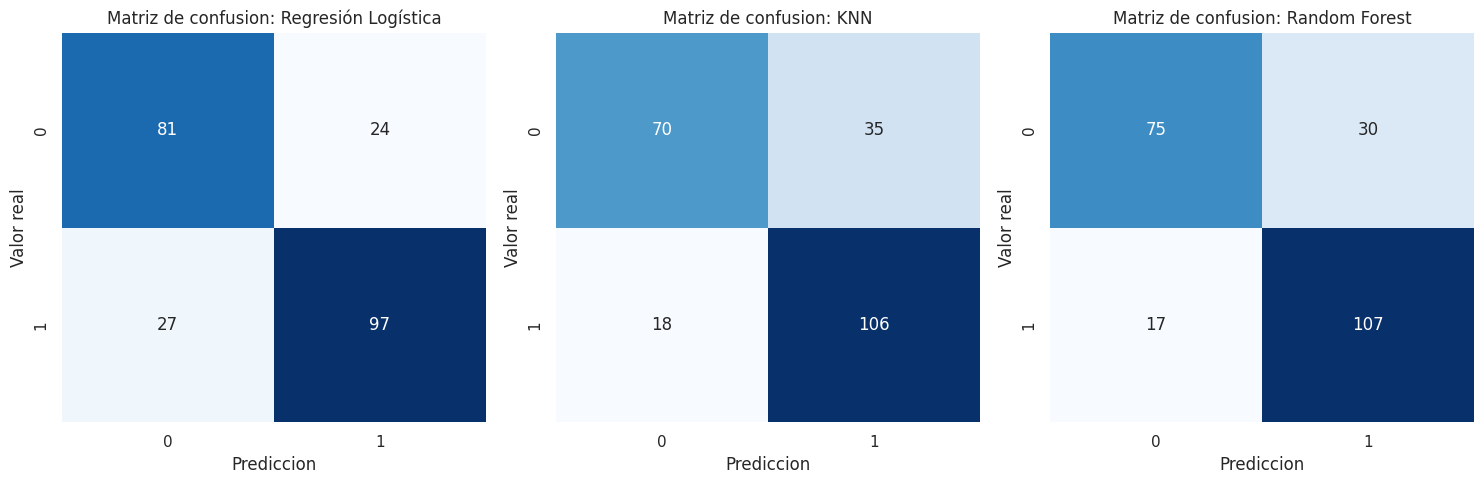


🏆 El mejor modelo general es: Random Forest (F1-Score: 0.8199)


In [36]:
modelo_nombre= ""
mejor_f1= 0
mejor_modelo= None

fig, axes= plt.subplots(1, 3, figsize=(15, 5))
axes= axes.flatten()

for i, (nombre, modelo) in enumerate(mejores_modelos.items()):
  y_pred= modelo.predict(x_test_scaled)
  print(f"****{nombre}****")
  print(classification_report(y_test, y_pred))

  f1_actual= f1_score(y_test, y_pred)
  if f1_actual > mejor_f1:
    mejor_f1= f1_actual
    mejor_nombre= nombre
    mejor_modelo= modelo



  cm= confusion_matrix(y_test, y_pred)
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
  axes[i].set_title(f'Matriz de confusion: {nombre}')
  axes[i].set_xlabel('Prediccion')
  axes[i].set_ylabel('Valor real')

plt.tight_layout()
plt.show()

print(f"\n🏆 El mejor modelo general es: {mejor_nombre} (F1-Score: {mejor_f1:.4f})")

### **Nota Científica: Evaluación y Comparación de Modelos con Métricas de Clasificación y Matriz de Confusión**

Este bloque se dedica a la evaluación detallada de los modelos entrenados. Para cada modelo, se calcula la predicción sobre el conjunto de prueba y se genera un `classification_report` que incluye métricas como precisión, recall y F1-score. La matriz de confusión se visualiza utilizando `seaborn.heatmap`, proporcionando una representación gráfica de los verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos. Además, se identifica el 'mejor' modelo basándose en el F1-score, que es una métrica clave cuando existe un desequilibrio de clases o cuando tanto la precisión como el recall son importantes.

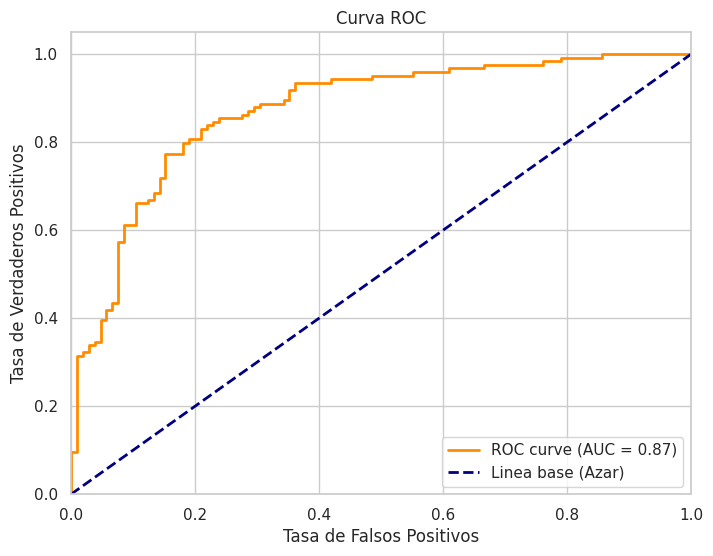

In [37]:
plt.figure(figsize=(8, 6))

y_prod= mejor_modelo.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, umbrales= roc_curve(y_test, y_prod)
roc_auc= auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Linea base (Azar)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

### **Nota Científica: Análisis de Rendimiento Mediante Curva ROC**

La curva *Receiver Operating Characteristic* (ROC) es una herramienta gráfica esencial para evaluar el rendimiento de un clasificador binario. En este bloque, se calcula la curva ROC y el Área Bajo la Curva (AUC) para el `mejor_modelo` identificado previamente. El AUC proporciona una medida agregada del rendimiento del modelo en todos los umbrales de clasificación; un valor cercano a 1.0 indica un excelente poder discriminatorio. La visualización de la curva ROC junto con una línea base (azar) permite juzgar visualmente qué tan bien el modelo distingue entre las clases positiva y negativa.

## Análisis y Comparación de Resultados (Paso 5)

Esta tabla condensa las conclusiones para que las agregues en una celda de texto (Markdown) al final de tu libreta, justificando tus decisiones ante quien evalúe el proyecto:

| Modelo Evaluado        | Fortalezas en este Contexto                                                                             | Debilidades en este Contexto                                                                                                            | Veredicto                                                                                                                                                             |
|:-----------------------|:--------------------------------------------------------------------------------------------------------|:----------------------------------------------------------------------------------------------------------------------------------------|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Regresión Logística    | Muy rápido de entrenar y altamente interpretable. Permite ver exactamente qué variables físicas (ej. alcohol) aumentan la probabilidad de calidad. | Asume que existe una relación lineal estricta entre los químicos y la calidad del vino, lo cual rara vez ocurre en la fermentación natural. | Buen modelo base, pero generalmente superado por algoritmos no lineales en este tipo de química compleja.                                                            |
| KNN (K-Nearest Neighbors) | Excelente para capturar similitudes químicas locales (vinos con perfiles idénticos tienden a tener la misma calidad).                       | Sensible a la dimensionalidad. Al tener tantas variables químicas, calcular la distancia geométrica perfecta se vuelve matemáticamente difuso. | Rendimiento intermedio. Dependió enormemente de nuestro escalado de datos previo.                                                                                 |
| Random Forest          | Identifica relaciones complejas y no lineales sin esfuerzo. Inmune a diferencias de escala.             | Funciona como una "caja negra" compleja, lo que dificulta explicar la decisión final molécula por molécula.                          | El Mejor Modelo. Su capacidad de ensamblar múltiples árboles de decisión maneja perfectamente los patrones ocultos en el dataset de vinos. |
